![header](../figures/logos_partenaires._cmems_se.jpg)

# Benchmark DUACS Lagrangian Cumulative Distance

<div style="text-align: right"><i> 2023-04-27 DUACS_SSH_BENCHMARK_DEMO </i></div>

***
**Authors:**  CLS & Datlas <br>
**Copyright:** 2023 CLS & Datlas <br>
**License:** MIT

<div class="alert alert-block alert-success">
<h1><center>Benchmark of DUACS sea surface height maps</center></h1>
<h5> The notebook aims to evaluate the sea surface height maps produced by the DUACS system. </h5>
    <h5> These maps are equivalent to the SEALEVEL_GLO_PHY_L4_MY_008_047 product distributed by the Copernicus Marine Service, except that a nadir altimeter (SARAL/Altika, SEALEVEL_GLO_PHY_L3_MY_008_062 product) has been excluded from the mapping. </h5>
        <h5> We provide below a demonstration of the validation of these maps against the trajectories of independent drifters distributed by CMEMS </h5>
</div>

# 1. Import packages

In [1]:
import os
import numpy as np
import xarray as xr 
import matplotlib
import matplotlib.pylab as plt 
import matplotlib.ticker as mticker
import cmocean 
from scipy.interpolate import RegularGridInterpolator
import pickle
import gc
from matplotlib import cm 
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

import sys
sys.path.append('..')
from src.mod_plot import *
from src.mod_traj import *
from src.mod_compare import regional_zoom

# 2. Setup parameters

In [16]:
method_name = 'DUACS_global'

time_min = '2023-01-01'                                        # time min for analysis
time_max = '2023-12-31'                                        # time max for analysis 

dir_out = f'../results/'                               # output directory path 
prefix_out = 'dict_drifter_adv'
results_out = 'deviat_uv_'+method_name+'.nc'

if not os.path.exists(dir_out):
    os.system('mkdir '+dir_out)

# Global
lon_min = 0                                          # domain min longitude
lon_max = 360                                          # domain max longitude
lat_min = -90.                                          # domain min latitude
lat_max = 90.                                          # domain max latitude 


# 3. Maps to evaluate

## 3.1 Download maps

In [3]:
path_maps =  "/Odyssey/public/glorys/rec/glorys4_global_1patch10y/nrt_2023_global_4/test_data_14_geostrophic_velocities.nc"
#FOR 2019 : "/Odyssey/public/glorys/rec/glorys4_global_1patch10y/processed_2019_global_4/test_data_14.nc"

#f'../data/maps/DUACS_global_allsat-alg/dt*'

maps = xr.open_dataset("/Odyssey/private/d21botvy/cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.125deg_P1D_multi-vars_179.94W-179.94E_89.94S-89.94N_2023-01-01-2023-12-31.nc") #xr.open_mfdataset(path_maps)

'''maps = maps.rename({'out' : 'ssh'})
maps = maps.rename({'lon' : 'longitude'})
maps = maps.rename({'lat' : 'latitude'})
'''

maps.coords['longitude'] = (maps.coords['longitude'] + 360) % 360
maps = maps.sortby(['longitude'])
#ds_maps = ds_maps.sortby('time')
maps.latitude.attrs['units'] = 'degrees_north'
maps.longitude.attrs['units'] = 'degrees_east'
maps = maps.sortby('time')

maps = maps.sel({'longitude':slice(lon_min-0.5,lon_max+0.5)})
maps = maps.sel({'latitude':slice(lat_min-0.5,lat_max+0.5)})
maps

<xarray.Dataset> Size: 7GB
Dimensions:    (time: 337, latitude: 680, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 3kB 2023-01-15 2023-01-16 ... 2023-12-17
  * latitude   (latitude) float64 5kB -80.0 -79.75 -79.5 ... 89.25 89.5 89.75
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    ssh        (time, latitude, longitude) float32 1GB dask.array<chunksize=(337, 680, 1440), meta=np.ndarray>
    sla        (time, latitude, longitude) float64 3GB dask.array<chunksize=(337, 680, 1440), meta=np.ndarray>
    ugos       (time, latitude, longitude) float32 1GB dask.array<chunksize=(337, 680, 1440), meta=np.ndarray>
    vgos       (time, latitude, longitude) float32 1GB dask.array<chunksize=(337, 680, 1440), meta=np.ndarray>

## 3.2 Retrieve maps info 

In [6]:
# Constants
g = 9.81  # Gravity (m/s²)
omega = 7.2921e-5  # Earth's rotation rate (rad/s)
lat_to_rad = np.pi / 180.0

def coriolis(lat):
    """Calculate the Coriolis parameter."""
    return 2 * omega * np.sin(lat * lat_to_rad)

def calculate_geostrophic_velocities_cpu(ssh, lat, lon):
    """Calculate geostrophic velocities from SSH."""
    # Calculate spatial gradients of SSH
    dssh_dy = np.gradient(ssh, axis=0)  # Gradient along latitude
    dssh_dx = np.gradient(ssh, axis=1)  # Gradient along longitude

    # Convert lat/lon to meters for gradient scaling
    lat_spacing = np.gradient(lat) * 111e3  # Convert degrees to meters
    lon_spacing = np.gradient(lon) * 111e3 * np.cos(lat[:, None] * lat_to_rad)  # Broadcast lat to match SSH shape

    # Adjust gradients to physical units (m/m)
    dssh_dx /= lon_spacing
    dssh_dy /= lat_spacing[:, None]

    # Coriolis parameter
    f = coriolis(lat)
    #f_masked = np.where(f == 0, np.nan, f)  # Replace zero values with NaN to prevent division by zero
    f_masked = np.where(np.abs(lat) < 1e-5, np.nan, f)

    # Geostrophic velocities
    ugos = -g / f_masked[:, None] * dssh_dy  # u-component
    vgos = g / f_masked[:, None] * dssh_dx  # v-component

    return ugos, vgos

In [7]:
ssh = maps['sla'].values  # Assuming variable name is 'out'
lat = maps['latitude'].values  # Latitude
lon = maps['longitude'].values  # Longitude

# Compute geostrophic velocities on CPU
ugos_cpu, vgos_cpu = calculate_geostrophic_velocities_cpu(ssh, lat, lon)

maps["ugos"] = (('time', 'latitude', 'longitude'), ugos_cpu)
maps["vgos"] = (('time', 'latitude', 'longitude'), vgos_cpu)

# Retreive MDT relative to u and v
mdt_UV = xr.open_dataset('/homes/d21botvy/OCEAN_FORECAST/2023a_SSH_mapping_OSE/data/sad/mdt_cnes_cls18_global.nc')

# Generate new latitude and longitude values, 
# Only in case the resolution of ds_maps is not the same as the one of mdt_UV !
new_latitudes = ds_maps['latitude'].values #np.linspace(mdt_UV.latitude.min(), mdt_UV.latitude.max(), 720)
new_longitudes = ds_maps['longitude'].values #np.linspace(mdt_UV.longitude.min(), mdt_UV.longitude.max(), 1440)

# Interpolate the variable
# Only in case the resolution of ds_maps is not the same as the one of mdt_UV !
mdt_UV_interp = mdt_UV.interp(latitude=new_latitudes, longitude=new_longitudes)

MDT_u = np.repeat(mdt_UV_interp['u'][0].values[np.newaxis, :, :], 337, axis=0) # 337 IS THE NB OF DAYS THAT DS_MAPS CONTAIN
MDT_v = np.repeat(mdt_UV_interp['v'][0].values[np.newaxis, :, :], 337, axis=0) # 337 IS THE NB OF DAYS THAT DS_MAPS CONTAIN
ugos_cpu += MDT_u
vgos_cpu += MDT_v

maps["ugos"] = (('time', 'latitude', 'longitude'), ugos_cpu)
maps["vgos"] = (('time', 'latitude', 'longitude'), vgos_cpu)

In [7]:
time = maps.time.values
lon = maps.longitude.values
lat = maps.latitude.values 

time = (time.astype('datetime64[h]') - np.datetime64('2023-01-01')).astype(int)
Nt = time[-1] 

u_maps = maps.ugos
v_maps = maps.vgos
 

# 4. Independant drifters

## 4.1 Download drifters

In [4]:
from glob import glob

path_drifters = sorted(glob('/users/local/d21botvy/DRIFTERS_DIAGS/independent_drifters/uv_drifters_*.nc'))

ds_drifters = xr.open_mfdataset(path_drifters,concat_dim='time',combine='nested')
ds_drifters.load()

<xarray.Dataset> Size: 69MB
Dimensions:    (time: 2156405)
Coordinates:
  * time       (time) datetime64[ns] 17MB 2019-01-01 ... 2019-12-31
    latitude   (time) float32 9MB -20.17 -20.12 -20.07 ... -12.31 -16.64 -32.11
    longitude  (time) float32 9MB 87.07 87.05 87.03 86.98 ... 86.61 121.6 95.08
Data variables:
    EWCT       (time) float32 9MB -0.1013 -0.0971 -0.1572 ... -0.04298 -0.07795
    NSCT       (time) float32 9MB 0.2415 0.2573 0.2443 ... 0.03121 -0.1021
    sensor_id  (time) float64 17MB 1.163e+05 1.163e+05 ... 6.822e+07 6.831e+07
Attributes: (12/46)
    data_type:                   OceanSITES trajectory data
    format_version:              2.0
    platform_code:               116275
    date_update:                 2020-10-13T12:17:40Z
    institution:                 AOML
    institution_edmo_code:       1799
    ...                          ...
    deployment_lat:              -58.44
    last_longitude_observation:  82.75
    last_latitude_observation:   -18.49
    date_drog_lost:              2017-01-21T03:37:00Z
    death_type:                  stop transmitting
    last_date_observation:       2019-01-16T01:51:00Z

## 4.2 Prepare drifter data

In [5]:
%%time
ind, time_drifter, lon_drifter, lat_drifter, id_drifter= prepare_drifter_data(ds_drifters,maps)

CPU times: user 1.61 s, sys: 142 ms, total: 1.76 s
Wall time: 3.39 s


# 5. Interpolate maps at drifters locations

In [8]:
%%time

# Create interpolation function
fu = RegularGridInterpolator((time, lat, lon), u_maps.values)
fv = RegularGridInterpolator((time, lat, lon), v_maps.values)

CPU times: user 1.77 s, sys: 939 ms, total: 2.71 s
Wall time: 2.9 s


# 6. Artificial drifter trajectories 

## 6.1 Trajectory parameters and initialization 

In [9]:
nday = 5
dt_h = 24 
mode = 'euler' 
write = False 
Np = time_drifter.size

horizons = np.arange(0,nday*24/dt_h+1)

dict_drifter_adv_maps = {0:{'time':time_drifter,
                           'lon':lon_drifter,
                           'lat':lat_drifter,
                            'id':id_drifter}
                       }
horizons

array([0., 1., 2., 3., 4., 5.])

## 6.2 Compute trajectories

In [12]:
%%time
dict_drifter_adv_maps = compute_traj(dict_drifter_adv_maps, horizons, fu, fv ,Np, Nt, dt_h, method_name, dir_out, prefix_out, mode, write)


h 1.0
h 2.0.0
h 3.0.0
h 4.0.0
h 5.0.0
CPU times: user 39min 40s, sys: 3.63 s, total: 39min 43s
Wall time: 40min


# 7. Compute deviation  

In [13]:
# Deviation = Cumulative distance between artificial and real trajectories

# Average deviation by bins
lon_out=np.arange(lon_min, lon_max, 1)
lat_out=np.arange(lat_min, lat_max, 1)

horizon_days = [1,2,3,4,5]
    
dev_maps, var_dev_maps, dmean = compute_deviation(dict_drifter_adv_maps, Nt, dt_h, horizon_days,lon_out,lat_out, dir_out, method_name, results_out)


# 8. Plots

## 8.1 Plot deviation maps at different horizons

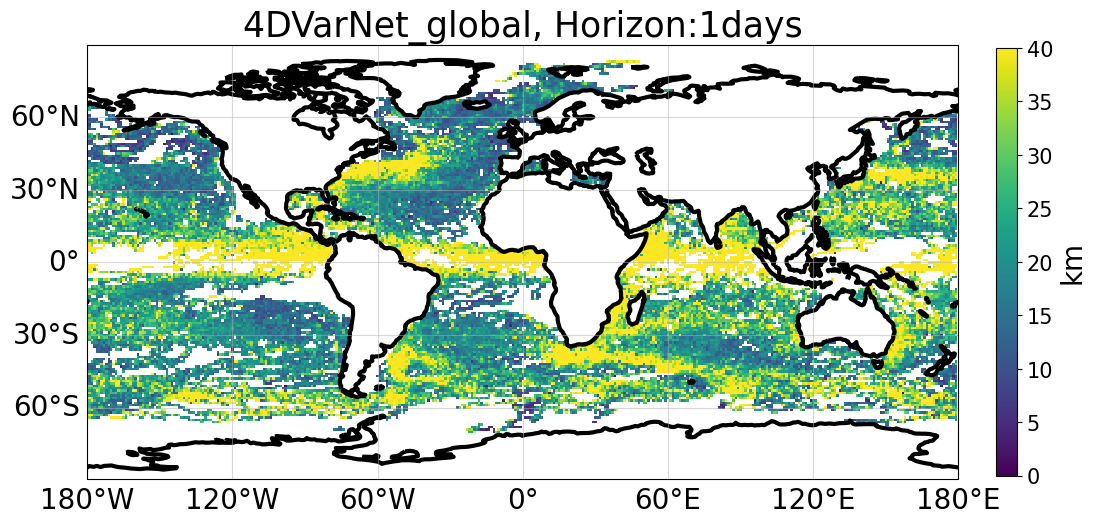

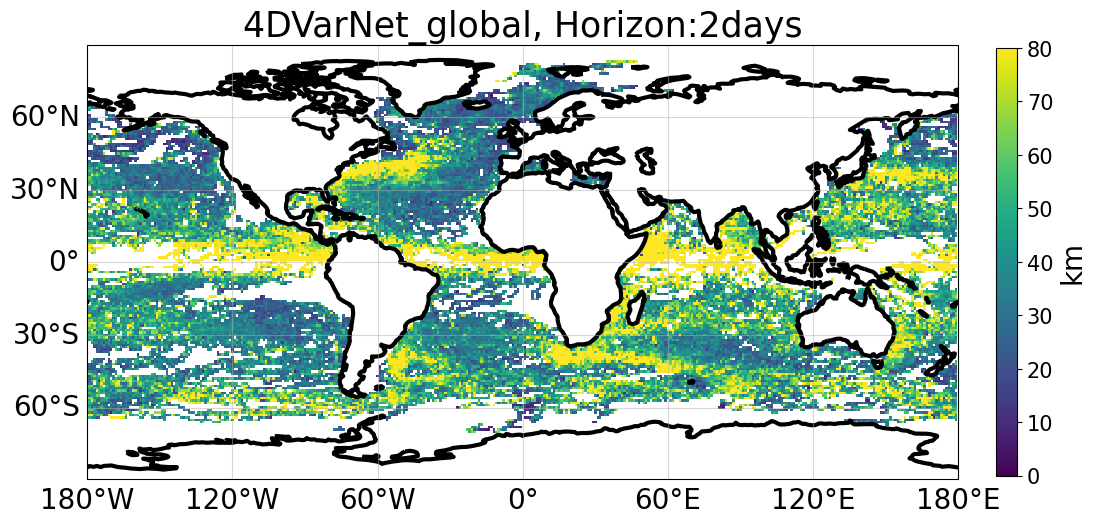

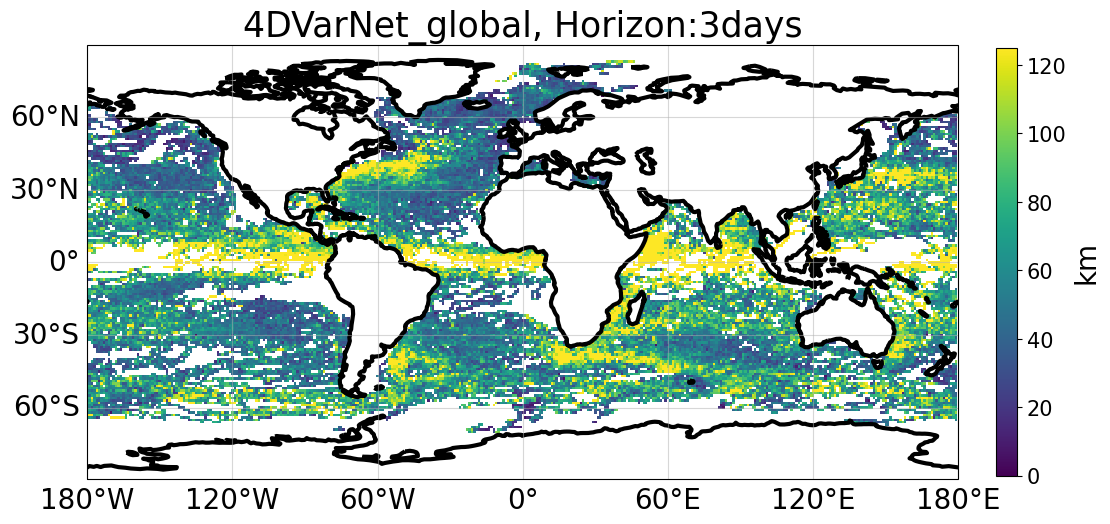

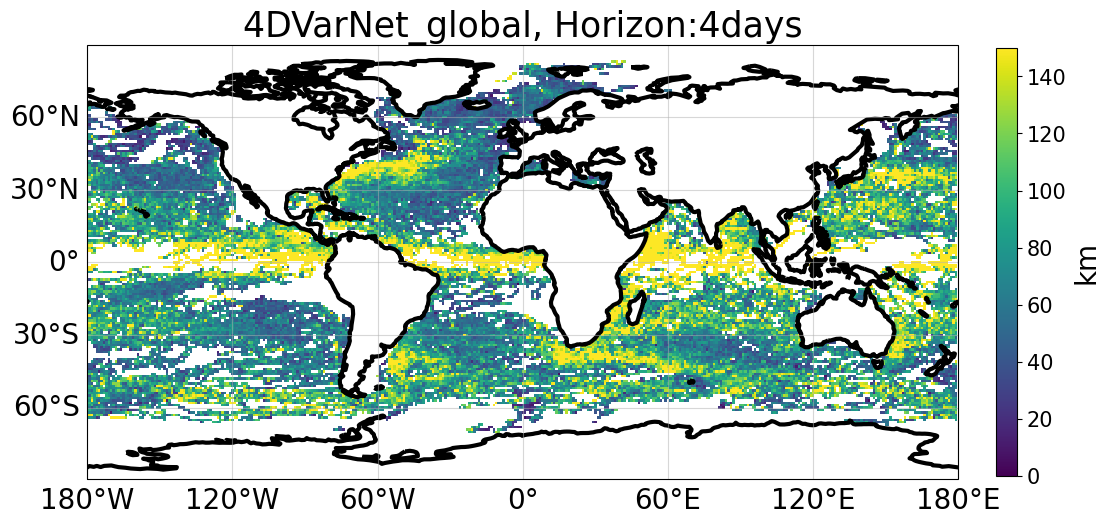

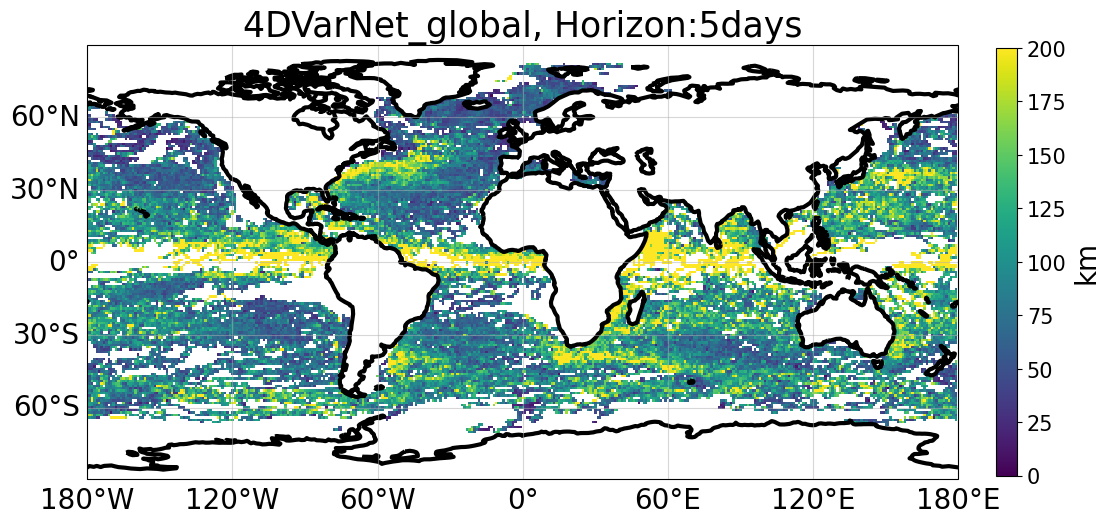

In [14]:
horizon_plots = [1,2,3,4,5]
horizon_plot_max = [40,80,125,150,200]

plot_traj_deviation_maps(lon_out, lat_out, dev_maps, dt_h,horizon_plots,horizon_plot_max,method_name) 


## 8.2 Plot spatially averaged deviation as a function of horizons

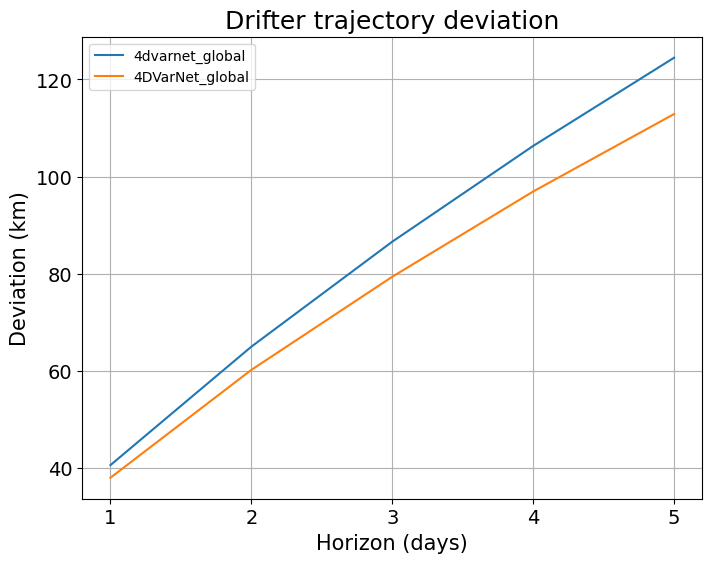

In [15]:
plot_meantraj_deviation(dir_out)

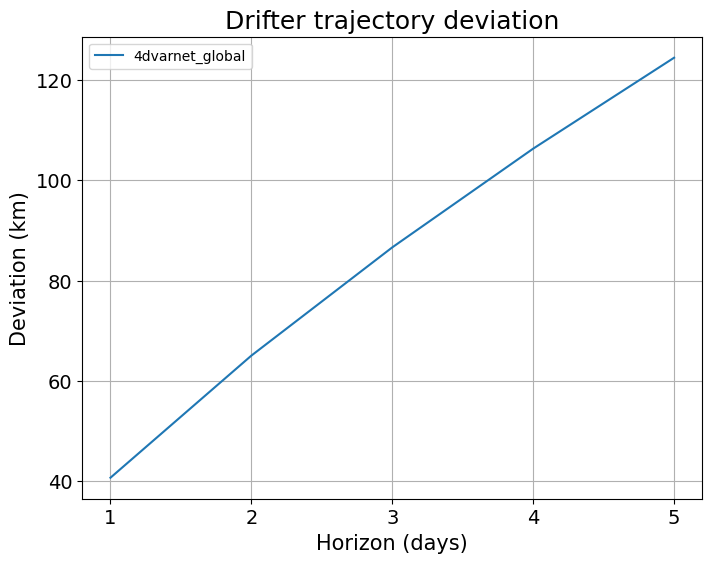

In [19]:
plot_meantraj_deviation(dir_out, just_basin='global')